# 解惑

## inference_collate_batch 自定义函数

这段代码定义了一个名为 `inference_collate_batch` 的函数，其作用是将一批数据样本整理（collate）成模型推理所需的格式。在深度学习中，尤其是使用 PyTorch 进行推理时，通常需要将多个样本组合成一个批次（batch）输入给模型。下面详细解释其工作原理：


### **函数参数**
- `batch`：一个包含多个样本的列表，每个样本通常是一个元组 `(feat_paths, mels)`，其中：
  - `feat_paths`：音频特征文件的路径（字符串）。
  - `mels`：对应的梅尔频谱（Mel spectrogram），通常是一个 PyTorch 张量（Tensor）。


### **函数逻辑**
1. **解包输入批次**：
   ```python
   feat_paths, mels = zip(*batch)
   ```
   - `zip(*batch)` 是 Python 中的解包操作，将 `batch` 中的每个样本元组 `(feat_paths, mels)` 拆分为两个列表：
     - `feat_paths`：包含所有样本的特征文件路径。
     - `mels`：包含所有样本的梅尔频谱张量。

2. **堆叠梅尔频谱**：
   ```python
   return feat_paths, torch.stack(mels)
   ```
   - `torch.stack(mels)` 将多个梅尔频谱张量（假设形状相同，例如 `[n_mels, time_steps]`）在新的维度上堆叠，形成一个批次张量（形状通常为 `[batch_size, n_mels, time_steps]`）。
   - 最终返回一个元组 `(feat_paths, batch_mels)`，其中 `batch_mels` 是堆叠后的批次张量。


### **应用场景**
- **模型推理**：在测试或部署阶段，需要将多个样本组合成批次输入模型，以提高计算效率。
- **数据加载器（DataLoader）**：该函数通常作为 PyTorch `DataLoader` 的 `collate_fn` 参数，用于自定义批次的整理方式。例如：
  ```python
  from torch.utils.data import DataLoader

  test_loader = DataLoader(
      test_dataset,
      batch_size=8,
      collate_fn=inference_collate_batch  # 使用自定义整理函数
  )

  # 推理时：
  for feat_paths, batch_mels in test_loader:
      outputs = model(batch_mels)  # 模型处理批次数据
      # 处理输出...
  ```


### **注意事项**
- **张量形状一致性**：`torch.stack` 要求所有 `mels` 张量的形状必须相同。如果梅尔频谱长度不同（例如不同时长的音频），则需要先进行填充（padding）。
- **与训练阶段的区别**：训练时的 `collate_fn` 可能需要处理标签（labels），而此函数仅处理特征路径和梅尔频谱，适用于无标签的推理场景。


## mean 全局平均池化

在深度学习中，`mean` 操作通常指对张量的某个维度求平均值。在你提供的代码中，`out.mean(dim=1)` 是对时序维度（`dim=1`）进行全局平均池化（Global Average Pooling）。下面我用具体例子说明这个过程。


### **`mean` 操作的数学定义**
对于输入张量 \( X \in \mathbb{R}^{B \times T \times D} \)（形状为 `(batch_size, seq_length, d_model)`），沿维度 \( 1 \)（时序维度 \( T \)）的平均值计算为：

\[
\text{output}[b, d] = \frac{1}{T} \sum_{t=0}^{T-1} X[b, t, d]
\]

其中：
- \( b \) 是批次索引（范围 \( 0 \leq b < B \)）。
- \( d \) 是特征维度索引（范围 \( 0 \leq d < D \)）。
- \( t \) 是时序索引（范围 \( 0 \leq t < T \)）。


### **示例说明**
假设输入张量 `out` 的形状为 `(2, 3, 4)`（批次大小=2，序列长度=3，特征维度=4），具体数值如下：

```python
# 批次中的第一个样本 (b=0)
out[0] = [
  [1, 2, 3, 4],  # 第1帧特征 (t=0)
  [5, 6, 7, 8],  # 第2帧特征 (t=1)
  [9, 10, 11, 12]  # 第3帧特征 (t=2)
]

# 批次中的第二个样本 (b=1)
out[1] = [
  [10, 20, 30, 40],  # 第1帧特征 (t=0)
  [50, 60, 70, 80],  # 第2帧特征 (t=1)
  [90, 100, 110, 120]  # 第3帧特征 (t=2)
]
```



执行 `stats = out.mean(dim=1)` 后，结果为：

```python
# 形状: (2, 4)
stats = [
  [ (1+5+9)/3, (2+6+10)/3, (3+7+11)/3, (4+8+12)/3 ],      # 样本1的平均值
  [ (10+50+90)/3, (20+60+100)/3, (30+70+110)/3, (40+80+120)/3 ]  # 样本2的平均值
]

# 计算结果:
stats = [
  [ 5.0, 6.0, 7.0, 8.0 ],
  [ 50.0, 60.0, 70.0, 80.0 ]
]
```

### **代码验证**
以下是用PyTorch验证上述示例的代码：

In [2]:
import torch

# 创建示例张量
out = torch.tensor([
    [
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [9, 10, 11, 12]
    ],
    [
        [10, 20, 30, 40],
        [50, 60, 70, 80],
        [90, 100, 110, 120]
    ]
], dtype=torch.float32)

# 沿维度1求平均值
stats = out.mean(dim=1)

print("输入形状:", out.shape)  # 输出: torch.Size([2, 3, 4])
print("输出形状:", stats.shape)  # 输出: torch.Size([2, 4])
print("平均值结果:\n", stats)

输入形状: torch.Size([2, 3, 4])
输出形状: torch.Size([2, 4])
平均值结果:
 tensor([[ 5.,  6.,  7.,  8.],
        [50., 60., 70., 80.]])


### **在说话人识别中的作用**
在说话人识别任务中，`mean` 池化的核心作用是将**可变长度的时序特征**（不同音频长度对应不同的 `seq_length`）转换为**固定长度的全局特征**（形状为 `(batch_size, d_model)`）。这样做的好处是：
1. 消除了输入长度的差异，便于分类器处理。
2. 通过平均操作，聚合了整个音频的特征，捕获说话人的全局特征。


### **与其他池化方法的对比**
- **全局平均池化**（当前代码）：简单、计算高效，但对所有帧一视同仁。
- **全局最大池化**：取每个特征维度的最大值，可能突出重要特征，但易受噪声影响。
- **注意力池化**：根据重要性为不同帧分配权重，自适应地聚焦于关键特征（性能通常更好）。

如果需要更精细的特征聚合，可以考虑用注意力池化替代简单的平均池化。

## Transformer 内部向量维度变化情况

在PyTorch中，`nn.TransformerEncoderLayer` 的内部实现遵循标准Transformer架构，但有一些细节需要注意。下面我将详细解释代码中的Transformer层如何工作，以及数据维度的变化过程。


### **Transformer层的内部结构**
代码中的`encoder_layer`是一个标准的Transformer编码器层，包含两个核心子层：
1. **多头自注意力机制**（Multi-Head Self-Attention）
2. **前馈神经网络**（Feed Forward Network）

每层后都有残差连接和层归一化（Layer Normalization）。


### **关键参数解释**
```python
self.encoder_layer = nn.TransformerEncoderLayer(
    d_model=80,            # 输入特征维度
    dim_feedforward=256,   # 前馈网络隐藏层维度
    nhead=2,               # 注意力头数
    batch_first=True,      # 输入格式为 (batch, seq, feature)
    activation="gelu"      # 激活函数
)
```


### **前向传播过程及维度变化**
假设输入张量`out`的形状为`(batch_size, seq_length, d_model)`，即`(B, T, 80)`。下面是数据在Transformer层内的详细流动过程：


#### **1. 多头自注意力机制**
```python
# 输入：out (B, T, 80)
attn_output = self.self_attn(out, out, out)[0]  # 自注意力计算
# 输出：attn_output (B, T, 80)
```

**内部维度变化**：
1. **线性投影**：将输入`out`投影到查询(Q)、键(K)、值(V)三个矩阵：
   ```
   Q = Linear(out)  → (B, T, 80)
   K = Linear(out)  → (B, T, 80)
   V = Linear(out)  → (B, T, 80)
   ```
   
2. **分割多头**：将Q、K、V分割为多个头（`nhead=2`）：
   ```
   Q_split = Split(Q)  → (B, T, 2, 40)  # 每个头40维
   K_split = Split(K)  → (B, T, 2, 40)
   V_split = Split(V)  → (B, T, 2, 40)
   ```
   
3. **注意力计算**：对每个头独立计算注意力得分并加权：
   ```
   Attention(Q, K, V) = softmax(Q·K^T/√d_k)·V
   ```
   - 维度变化：`(B, T, 40) × (B, 40, T) → (B, T, T)`（注意力权重）
   - 再乘以V：`(B, T, T) × (B, T, 40) → (B, T, 40)`
   
4. **合并多头**：将各头的输出拼接并投影回原维度：
   ```
   attn_output = Concat(各头输出) → (B, T, 80)
   ```


#### **2. 第一个残差连接和层归一化**
```python
out = out + attn_output  # 残差连接
out = self.norm1(out)    # 层归一化
# 输出形状不变：(B, T, 80)
```


#### **3. 前馈神经网络（FFN）**
```python
ffn_output = self.linear2(self.dropout(self.activation(self.linear1(out))))
# 内部维度变化：
# linear1: (B, T, 80) → (B, T, 256)  # dim_feedforward=256
# activation + dropout
# linear2: (B, T, 256) → (B, T, 80)  # 投影回d_model
```


#### **4. 第二个残差连接和层归一化**
```python
out = out + ffn_output  # 残差连接
out = self.norm2(out)   # 层归一化
# 最终输出形状：(B, T, 80)
```


### **总结：维度变化全流程**

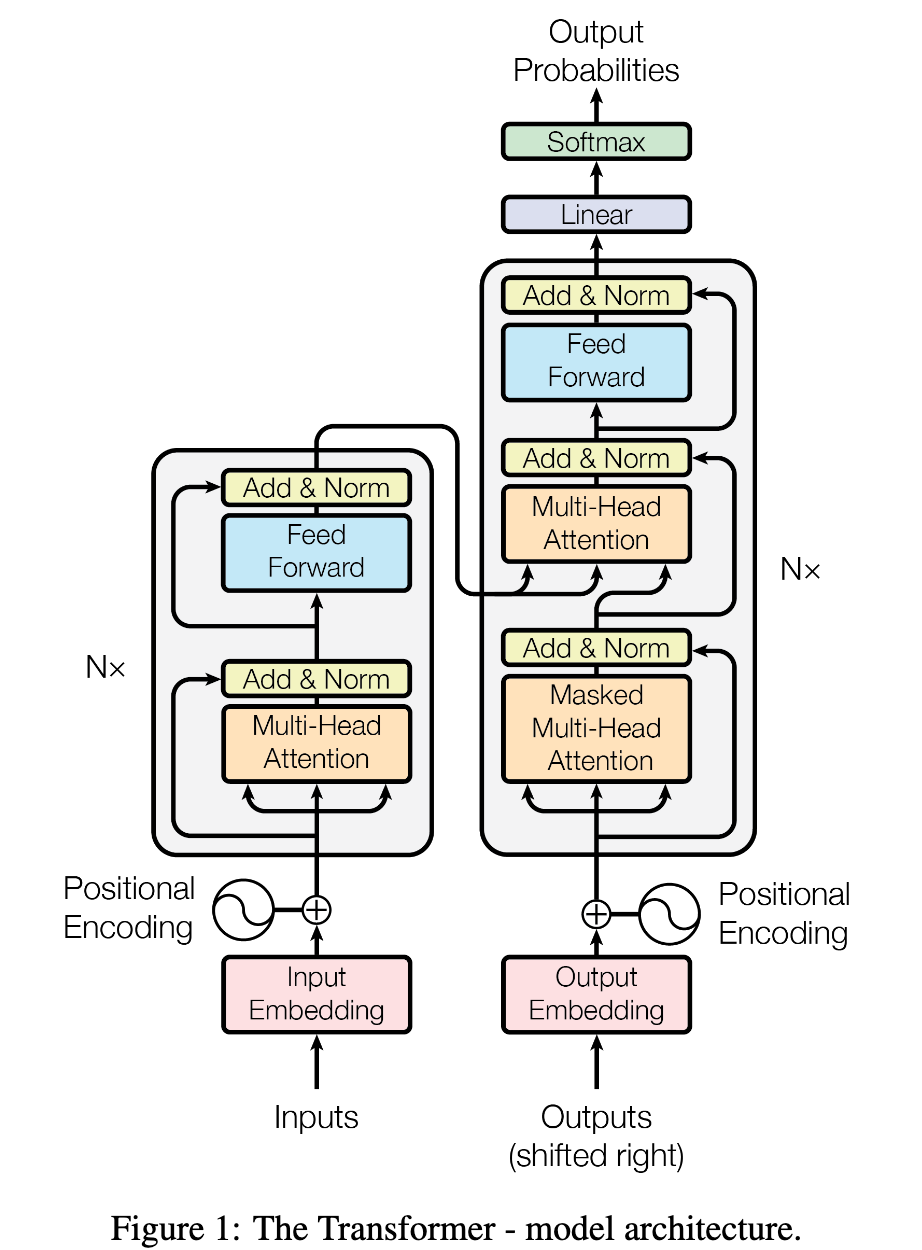

```
输入 out:                    (batch_size, seq_length, d_model) = (B, T, 80)
                              ↓
多头自注意力:
  Q, K, V 投影:              (B, T, 80) → (B, T, 80) × 3
  分割头:                    (B, T, 80) → (B, T, 2, 40)
  注意力计算:                (B, T, 40) → (B, T, 40)
  合并头:                    (B, T, 40×2) → (B, T, 80)
                              ↓
第一个残差+层归一化:          (B, T, 80) → (B, T, 80)
                              ↓
前馈网络:
  第一层线性变换:             (B, T, 80) → (B, T, 256)
  GELU激活:                  (B, T, 256) → (B, T, 256)
  第二层线性变换:             (B, T, 256) → (B, T, 80)
                              ↓
第二个残差+层归一化:          (B, T, 80) → (B, T, 80)
                              ↓
最终输出:                     (batch_size, seq_length, d_model)
```


### **设计选择的意义**
1. **多头机制**：通过`nhead=2`将特征分为多个子空间，使模型能同时关注不同位置的不同特征子空间。

2. **前馈网络扩张**：`dim_feedforward=256`创建了一个瓶颈结构，允许模型学习更复杂的非线性映射。

3. **GELU激活**：比ReLU更平滑，能减少梯度消失问题，尤其在深层网络中表现更好。

4. **残差连接**：确保信息能在深层网络中有效传递，缓解梯度消失。


### **潜在改进建议**
1. **增加层数**：当前模型只有一个Transformer层，可以考虑堆叠多个层以增强特征提取能力。

2. **调整头数和维度**：`nhead=2`和`d_model=80`可能不是最优组合，可以尝试更多配置。

3. **使用Conformer**：如代码注释所示，将Transformer替换为Conformer能更好地处理音频特征的时序特性。

4. **添加位置编码**：当前模型未显式使用位置编码，对于长序列可能会损失时序信息。

## get_cosine_schedule_with_warmup 学习率变化函数

这个函数 `get_cosine_schedule_with_warmup` 实现了一种学习率调度策略，结合了**线性预热（warmup）**和**余弦退火（cosine annealing）**两种机制。这种策略在深度学习训练中很常见，尤其适用于大型模型（如BERT、GPT等）。


### **函数概述**
该函数创建并返回一个 `LambdaLR` 学习率调度器，它会根据训练步数动态调整优化器的学习率。具体分为两个阶段：
1. **预热阶段**：学习率从0线性增加到初始学习率。
2. **余弦退火阶段**：学习率从初始值按照余弦函数曲线逐渐衰减到0。


### **参数解析**
- **`opt`**：PyTorch优化器（如Adam、SGD等），该调度器将应用于这个优化器。
- **`num_warmup_steps`**：预热阶段的步数。在此期间，学习率从0线性增长到初始学习率。
- **`num_training_steps`**：总训练步数。决定了整个训练过程的长度。
- **`num_cycles`**（默认0.5）：余弦退火的周期数。0.5表示半个周期，即学习率从初始值下降到0。
- **`last_epoch`**（默认-1）：上一次训练的最后一个epoch，用于恢复训练时继续之前的学习率调度。


### **学习率计算逻辑**
核心是内部的 `lr_lambda` 函数，它根据当前步数返回一个学习率缩放因子：

#### **1. 预热阶段（Warmup）**
当 `current_step < num_warmup_steps` 时：

$$缩放因子 = \frac{current_step}{num_warmup_steps}$$

- 学习率从0开始，线性增加到初始学习率。例如：
  - 第1步：缩放因子=0.001 → 学习率=0.001×初始值
  - 第500步：缩放因子=0.5 → 学习率=0.5×初始值
  - 第1000步（假设warmup=1000）：缩放因子=1.0 → 学习率=初始值

#### **2. 余弦退火阶段（Cosine Annealing）**
当 `current_step ≥ num_warmup_steps` 时：

$$progress = \frac{current_step - num_warmup_steps}{num_training_steps - num_warmup_steps}$$


$$缩放因子 = 0.5 \times \left(1 + \cos\left(\pi \times num_cycles \times 2 \times progress\right)\right)$$

- **关键参数**：`num_cycles` 控制余弦函数的周期数：
  - **num_cycles=0.5**（默认）：学习率从初始值平滑下降到0（半个余弦周期）。
  - **num_cycles=1.0**：学习率先下降到0，再上升回到初始值（一个完整周期）。
  - **num_cycles=2.0**：学习率会经历两次下降-上升的循环。



## schedule.step()

在PyTorch中，学习率调度器（如 `get_cosine_schedule_with_warmup` 返回的 `LambdaLR`）之所以可以调用 `.step()` 方法，是因为它们都继承自 `_LRScheduler` 基类，该基类定义了统一的接口用于更新优化器的学习率。


### **1. 调度器的工作原理**
`get_cosine_schedule_with_warmup` 返回的是一个 `LambdaLR` 对象，它通过传入的 `lr_lambda` 函数计算学习率缩放因子。每次调用 `.step()` 时，调度器会根据当前的训练步数（或epoch数）更新优化器中所有参数组的学习率。


### **2. `.step()` 方法的作用**
在训练循环中调用 `scheduler.step()` 是为了：
1. 记录当前训练步数（或epoch数）。
2. 根据预设的策略（如线性warmup+余弦退火）计算新的学习率。
3. 更新优化器中所有参数组的学习率。

示例代码：
```python
for epoch in range(num_epochs):
    for batch in dataloader:
        # 前向传播、反向传播
        optimizer.step()          # 更新模型参数
        scheduler.step()          # 更新学习率
        current_lr = optimizer.param_groups[0]['lr']  # 获取当前学习率
```


### **3. 不同调度器的调用时机**
根据PyTorch官方文档，不同类型的调度器 `.step()` 的调用时机不同：
- **基于epoch的调度器**（如 `StepLR`、`CosineAnnealingLR`）：  
  通常在每个epoch结束后调用 `scheduler.step()`。
  
- **基于迭代的调度器**（如 `LambdaLR`、`ReduceLROnPlateau`）：  
  通常在每个batch迭代后调用 `scheduler.step()`，尤其当你的warmup步数或总训练步数是以batch为单位计算时。

你使用的 `get_cosine_schedule_with_warmup` 属于**基于迭代的调度器**，因为它的warmup和总步数是通过 `num_warmup_steps` 和 `num_training_steps` 指定的，因此需要在每个batch后调用 `.step()`。


### **4. 注意事项**
- **避免重复调用**：确保在一个训练迭代中只调用一次 `scheduler.step()`，否则可能导致学习率异常。
- **恢复训练**：如果需要从检查点恢复训练，可能需要手动设置 `last_epoch` 参数以正确恢复学习率状态。

## 解释代码中：数据处理时，训练数据在batch中要控制seq_length，而推理不需要

在深度学习任务中，训练和推理阶段对数据的处理方式通常存在差异。在你提供的代码中，`myDataset`（训练数据集）控制了序列长度，而`InferenceDataset`（推理数据集）没有，这主要基于以下设计考虑：


### **1. 训练阶段控制序列长度的原因**
在`myDataset`的`__getitem__`方法中，通过以下逻辑控制序列长度：
```python
if len(mel) > self.segment_len:
    start = random.randint(0, len(mel) - self.segment_len)
    mel = mel[start: start + self.segment_len]
else:
    mel = mel
```
**目的**：
- **批量处理需求**：训练时需要将多个样本组成批次（batch）输入模型，而模型要求批次内所有样本的形状一致。因此必须将变长序列（不同音频长度）统一为固定长度。
- **计算效率**：固定序列长度可优化GPU内存分配和矩阵运算效率。
- **数据增强**：随机截取片段（Random Cropping）可增加训练数据的多样性，提升模型泛化能力。


### **2. 推理阶段不控制序列长度的原因**
`InferenceDataset`的`__getitem__`直接返回原始梅尔频谱，不进行长度截断：
```python
def __getitem__(self, index):
    feat_path = utterance["feature_path"]
    mel = torch.load(os.path.join(self.data_dir, feat_path))
    return feat_path, mel
```
**原因分析**：
#### （1）**推理任务的特性**
   - 说话人识别模型在推理时需要利用**完整音频信息**进行判断，截断序列可能丢失关键特征（如语音的首尾部分可能包含说话人独特的发音习惯）。
   - 训练时通过随机截断已让模型学会处理不同位置的片段，推理时使用完整序列可提升准确率。

#### （2）**变长序列的批量处理方案**
   虽然推理数据集不截断序列，但通过`inference_collate_batch`函数处理变长序列：
   ```python
   def inference_collate_batch(batch):
       feat_paths, mels = zip(*batch)
       return feat_paths, torch.stack(mels)
   ```
   - **前提条件**：`torch.stack`要求所有`mels`的形状一致，因此实际使用时需要配合**填充（padding）** 或**动态批处理（Dynamic Batching）**。
   - **可能的隐藏处理**：  
     代码中未显式填充，但实际应用中可能有两种情况：
     1. 推理数据集中的音频长度已提前处理为一致（如通过预处理统一长度）。
     2. 使用支持变长序列的批处理方式（如PyTorch的`pack_padded_sequence`和`pad_packed_sequence`）。

#### （3）**与训练阶段的分工**
   - 训练阶段关注模型学习能力（通过截断+填充提升鲁棒性）。
   - 推理阶段关注模型预测效果（使用完整序列获取最佳性能）。


### **3. 变长序列在推理时的常见处理方式**
如果推理数据确实包含变长序列，通常有以下处理方案：
1. **动态批处理（Dynamic Batching）**  
   - 按序列长度分组，将长度相近的样本组成批次，减少填充量。
   - 例如：使用`torch.utils.data.DataLoader`的`collate_fn`自定义填充逻辑。

2. **显式填充（Padding）**  
   在`inference_collate_batch`中添加填充代码：
   ```python
   def inference_collate_batch(batch):
       feat_paths, mels = zip(*batch)
       # 找到最长序列的长度
       max_len = max(mel.size(0) for mel in mels)
       # 填充所有序列到max_len
       padded_mels = [F.pad(mel, (0, 0, 0, max_len - mel.size(0))) for mel in mels]
       return feat_paths, torch.stack(padded_mels)
   ```
   （注：假设mel的形状为`(seq_length, feature_dim)`）

3. **模型支持变长输入**  
   部分模型架构（如RNN、Transformer）天然支持变长序列，无需固定长度（但批处理时仍需填充）。


### **4. 代码中的潜在假设**
当前代码未对推理数据的序列长度做控制，可能基于以下假设：
- 推理数据集中的所有音频已被预处理为相同长度（如通过数据清洗或截断）。
- 模型在训练时已学会处理不同长度的序列，推理时通过全局平均池化（如代码中的`out.mean(dim=1)`）自动聚合特征，因此序列长度不影响最终分类结果。


### **总结**
训练阶段控制序列长度是为了满足批量训练的技术要求（形状一致+计算效率），而推理阶段更关注利用完整信息提升准确率。若推理数据确实包含变长序列，需在`collate_fn`中添加填充逻辑，或使用动态批处理方案。当前代码的设计符合说话人识别任务的常见实践。